In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.shape

(284807, 31)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
df.isna().sum().sum()

np.int64(0)

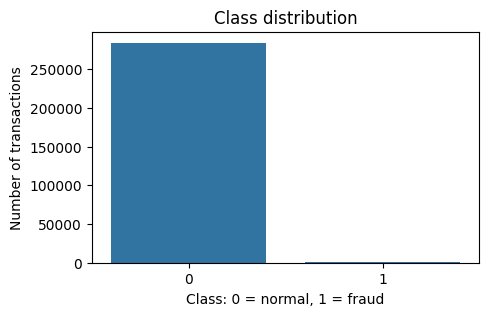

In [11]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x="Class")
plt.title("Class distribution")
plt.xlabel("Class: 0 = normal, 1 = fraud")
plt.ylabel("Number of transactions")
plt.show()

In [13]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

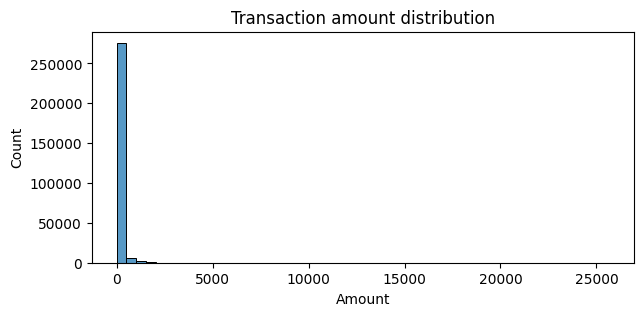

In [14]:
plt.figure(figsize=(7, 3))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction amount distribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

In [15]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


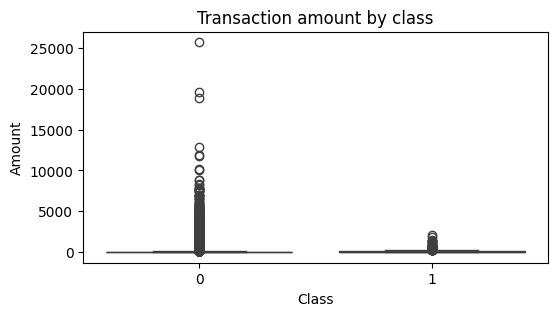

In [16]:
plt.figure(figsize=(6, 3))
sns.boxplot(data=df, x="Class", y="Amount")
plt.title("Transaction amount by class")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((227845, 30),
 (56962, 30),
 Class
 0    227451
 1       394
 Name: count, dtype: int64,
 Class
 0    56864
 1       98
 Name: count, dtype: int64)

In [18]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(X_train_scaled[["Time", "Amount"]])
X_test_scaled[["Time", "Amount"]] = scaler.transform(X_test_scaled[["Time", "Amount"]])

In [19]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

y_proba_logreg = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_logreg = (y_proba_logreg >= 0.5).astype(int)

In [23]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print(classification_report(y_test, y_pred_logreg))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))
print("PR-AUC:", average_precision_score(y_test, y_proba_logreg))

confusion_matrix(y_test, y_pred_logreg)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9721687370080279
PR-AUC: 0.7159122424484009


array([[55478,  1386],
       [    8,    90]])

In [21]:
df.shape
df["Class"].value_counts()
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [24]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(y_true, y_proba, threshold=0.5, model_name="model"):
    y_pred = (y_proba >= threshold).astype(int)
    
    print(f"Model: {model_name}")
    print(f"Threshold: {threshold}")
    print()
    print(classification_report(y_true, y_pred))
    
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))
    print("PR-AUC:", average_precision_score(y_true, y_proba))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    return {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

In [25]:
logreg_metrics = evaluate_model(
    y_test,
    y_proba_logreg,
    threshold=0.5,
    model_name="Logistic Regression"
)

Model: Logistic Regression
Threshold: 0.5

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9721687370080279
PR-AUC: 0.7159122424484009
Confusion matrix:
[[55478  1386]
 [    8    90]]


In [27]:
rf_metrics = evaluate_model(
    y_test,
    y_proba_rf,
    threshold=0.5,
    model_name="Random Forest"
)

Model: Random Forest
Threshold: 0.5

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.65      0.85      0.73        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9818797876494436
PR-AUC: 0.7999133196871797
Confusion matrix:
[[56819    45]
 [   15    83]]


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [53]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

hgb.fit(X_train, y_train, sample_weight=sample_weights)

y_proba_hgb = hgb.predict_proba(X_test)[:, 1]

In [56]:
hgb_metrics = evaluate_model(
    y_test,
    y_proba_hgb,
    threshold=0.5,
    model_name="HistGradientBoosting"
)

Model: HistGradientBoosting
Threshold: 0.5

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.29      0.88      0.44        98

    accuracy                           1.00     56962
   macro avg       0.64      0.94      0.72     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9609289762612979
PR-AUC: 0.716180722464244
Confusion matrix:
[[56653   211]
 [   12    86]]


In [58]:
results = pd.DataFrame([logreg_metrics, rf_metrics, hgb_metrics])
results

,model,threshold,roc_auc,pr_auc,precision,recall,f1
0,Logistic Regression,0.5,0.972169,0.715912,0.060976,0.918367,0.114358
1,Random Forest,0.5,0.981880,0.799913,0.648438,0.846939,0.734513
2,HistGradientBoosting,0.5,0.960929,0.716181,0.289562,0.877551,0.435443


In [29]:
thresholds = np.arange(0.01, 1.0, 0.01)

threshold_results = []

for threshold in thresholds:
    y_pred = (y_proba_rf >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.head()

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
0,0.01,0.001990,1.000000,0.003971,49159,0,98,7705
1,0.02,0.003833,0.989796,0.007636,25212,1,97,31652
2,0.03,0.006526,0.969388,0.012965,14462,3,95,42402
3,0.04,0.009636,0.959184,0.019080,9661,4,94,47203
4,0.05,0.013130,0.938776,0.025897,6915,6,92,49949


In [30]:
threshold_df.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
63,0.64,0.829787,0.795918,0.812500,16,20,78,56848
64,0.65,0.836957,0.785714,0.810526,15,21,77,56849
65,0.66,0.836957,0.785714,0.810526,15,21,77,56849
66,0.67,0.836957,0.785714,0.810526,15,21,77,56849
67,0.68,0.836957,0.785714,0.810526,15,21,77,56849
62,0.63,0.821053,0.795918,0.808290,17,20,78,56847
59,0.60,0.800000,0.816327,0.808081,20,18,80,56844
74,0.75,0.852273,0.765306,0.806452,13,23,75,56851
77,0.78,0.852273,0.765306,0.806452,13,23,75,56851
76,0.77,0.852273,0.765306,0.806452,13,23,75,56851


In [31]:
FP_COST = 5
FN_COST = 100

threshold_df["business_cost"] = (
    threshold_df["false_positives"] * FP_COST +
    threshold_df["false_negatives"] * FN_COST
)

threshold_df.sort_values("business_cost").head(10)

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives,business_cost
46,0.47,0.620438,0.867347,0.723404,52,13,85,56812,1560
45,0.46,0.615942,0.867347,0.720339,53,13,85,56811,1565
44,0.45,0.598592,0.867347,0.708333,57,13,85,56807,1585
43,0.44,0.578231,0.867347,0.693878,62,13,85,56802,1610
42,0.43,0.562914,0.867347,0.682731,66,13,85,56798,1630
47,0.48,0.631579,0.857143,0.727273,49,14,84,56815,1645
41,0.42,0.537975,0.867347,0.664062,73,13,85,56791,1665
51,0.52,0.674797,0.846939,0.751131,40,15,83,56824,1700
40,0.41,0.505952,0.867347,0.639098,83,13,85,56781,1715
50,0.51,0.658730,0.846939,0.741071,43,15,83,56821,1715


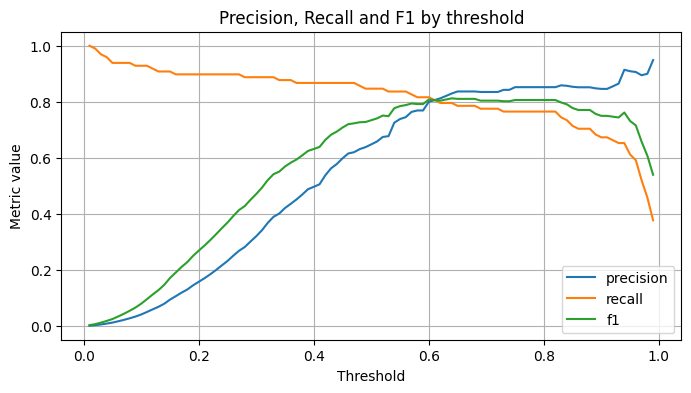

In [32]:
plt.figure(figsize=(8, 4))

plt.plot(threshold_df["threshold"], threshold_df["precision"], label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="f1")

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Precision, Recall and F1 by threshold")
plt.legend()
plt.grid(True)
plt.show()

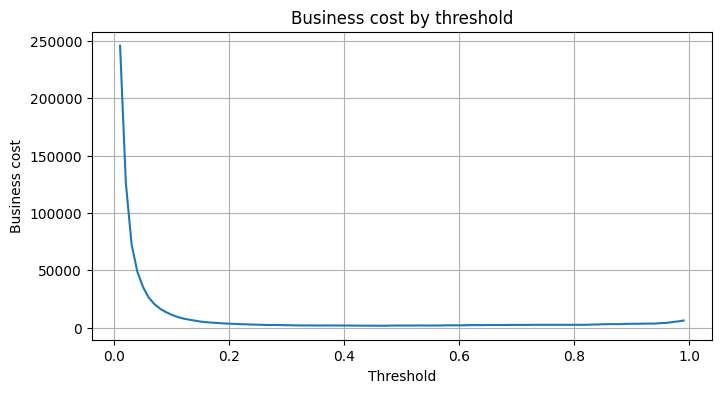

In [33]:
plt.figure(figsize=(8, 4))

plt.plot(threshold_df["threshold"], threshold_df["business_cost"])

plt.xlabel("Threshold")
plt.ylabel("Business cost")
plt.title("Business cost by threshold")
plt.grid(True)
plt.show()

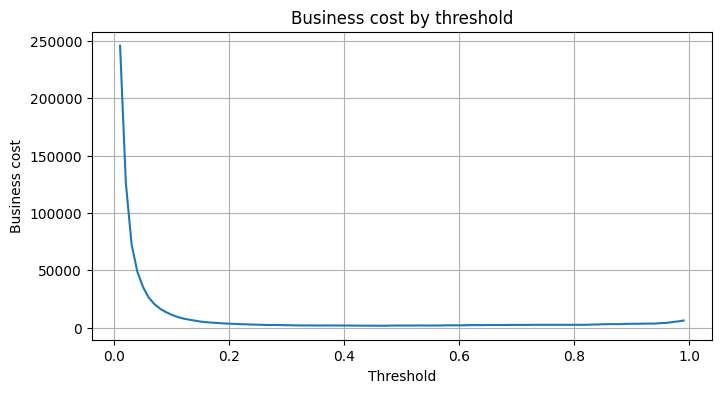

In [34]:
plt.figure(figsize=(8, 4))

plt.plot(threshold_df["threshold"], threshold_df["business_cost"])

plt.xlabel("Threshold")
plt.ylabel("Business cost")
plt.title("Business cost by threshold")
plt.grid(True)
plt.show()

In [35]:
threshold_df.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives,business_cost
63,0.64,0.829787,0.795918,0.812500,16,20,78,56848,2080
64,0.65,0.836957,0.785714,0.810526,15,21,77,56849,2175
65,0.66,0.836957,0.785714,0.810526,15,21,77,56849,2175
66,0.67,0.836957,0.785714,0.810526,15,21,77,56849,2175
67,0.68,0.836957,0.785714,0.810526,15,21,77,56849,2175
62,0.63,0.821053,0.795918,0.808290,17,20,78,56847,2085
59,0.60,0.800000,0.816327,0.808081,20,18,80,56844,1900
74,0.75,0.852273,0.765306,0.806452,13,23,75,56851,2365
77,0.78,0.852273,0.765306,0.806452,13,23,75,56851,2365
76,0.77,0.852273,0.765306,0.806452,13,23,75,56851,2365


In [36]:
threshold_df.sort_values("business_cost").head(10)

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives,business_cost
46,0.47,0.620438,0.867347,0.723404,52,13,85,56812,1560
45,0.46,0.615942,0.867347,0.720339,53,13,85,56811,1565
44,0.45,0.598592,0.867347,0.708333,57,13,85,56807,1585
43,0.44,0.578231,0.867347,0.693878,62,13,85,56802,1610
42,0.43,0.562914,0.867347,0.682731,66,13,85,56798,1630
47,0.48,0.631579,0.857143,0.727273,49,14,84,56815,1645
41,0.42,0.537975,0.867347,0.664062,73,13,85,56791,1665
51,0.52,0.674797,0.846939,0.751131,40,15,83,56824,1700
40,0.41,0.505952,0.867347,0.639098,83,13,85,56781,1715
50,0.51,0.658730,0.846939,0.741071,43,15,83,56821,1715


In [37]:
final_threshold = 0.47

final_rf_metrics = evaluate_model(
    y_test,
    y_proba_rf,
    threshold=final_threshold,
    model_name="Random Forest with selected threshold"
)

Model: Random Forest with selected threshold
Threshold: 0.47

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.62      0.87      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9818797876494436
PR-AUC: 0.7999133196871797
Confusion matrix:
[[56812    52]
 [   13    85]]


In [38]:
def make_decision(fraud_probability):
    if fraud_probability < 0.20:
        return "approve"
    elif fraud_probability < 0.47:
        return "review"
    else:
        return "block"

In [39]:
test_probabilities = [0.05, 0.25, 0.62]

for p in test_probabilities:
    print(p, "->", make_decision(p))

0.05 -> approve
0.25 -> review
0.62 -> block


In [40]:
predictions_df = X_test.copy()
predictions_df["true_class"] = y_test
predictions_df["fraud_probability"] = y_proba_rf
predictions_df["decision"] = predictions_df["fraud_probability"].apply(make_decision)

predictions_df[["Amount", "Time", "true_class", "fraud_probability", "decision"]].head(10)

,Amount,Time,true_class,fraud_probability,decision
263020,23.00,160760.0,0,0.006696,approve
11378,11.85,19847.0,0,0.013752,approve
147283,76.07,88326.0,0,0.031988,approve
219439,0.99,141734.0,0,0.008085,approve
36939,1.50,38741.0,0,0.263305,review
243438,8.99,151934.0,0,0.014585,approve
259448,52.00,159122.0,0,0.019618,approve
43800,3.59,41656.0,0,0.017244,approve
66742,27.92,52202.0,0,0.016137,approve
66499,95.25,52081.0,0,0.016996,approve


In [41]:
predictions_df["decision"].value_counts()

decision
approve    56407
review       418
block        137
Name: count, dtype: int64

In [42]:
from pathlib import Path

FIGURES_DIR = Path("../reports/figures")
MODELS_DIR = Path("../models")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

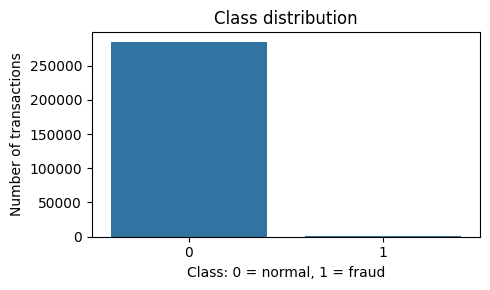

In [43]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x="Class")
plt.title("Class distribution")
plt.xlabel("Class: 0 = normal, 1 = fraud")
plt.ylabel("Number of transactions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300)
plt.show()

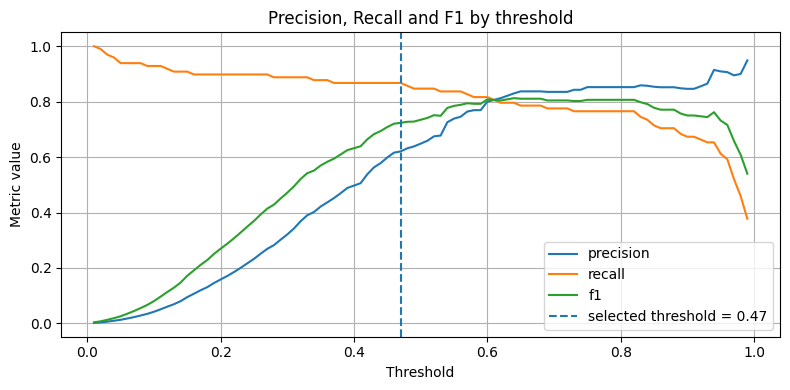

In [44]:
plt.figure(figsize=(8, 4))

plt.plot(threshold_df["threshold"], threshold_df["precision"], label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="f1")

plt.axvline(0.47, linestyle="--", label="selected threshold = 0.47")

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Precision, Recall and F1 by threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_metrics.png", dpi=300)
plt.show()

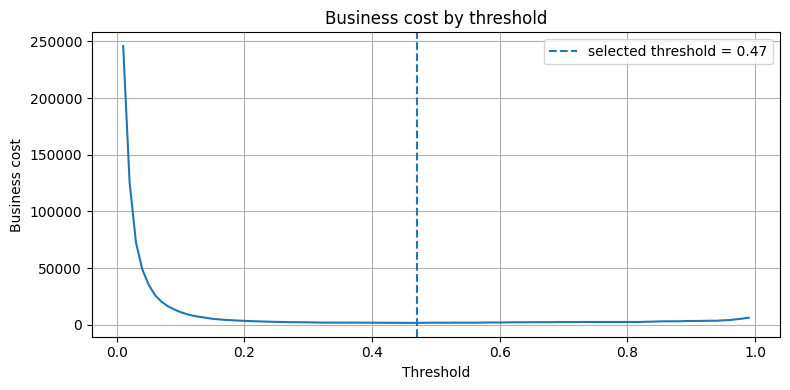

In [45]:
plt.figure(figsize=(8, 4))

plt.plot(threshold_df["threshold"], threshold_df["business_cost"])
plt.axvline(0.47, linestyle="--", label="selected threshold = 0.47")

plt.xlabel("Threshold")
plt.ylabel("Business cost")
plt.title("Business cost by threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "business_cost_by_threshold.png", dpi=300)
plt.show()

In [46]:
final_threshold = 0.47

final_rf_metrics = evaluate_model(
    y_test,
    y_proba_rf,
    threshold=final_threshold,
    model_name="Random Forest with selected threshold"
)

Model: Random Forest with selected threshold
Threshold: 0.47

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.62      0.87      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9818797876494436
PR-AUC: 0.7999133196871797
Confusion matrix:
[[56812    52]
 [   13    85]]


<Figure size 500x400 with 0 Axes>

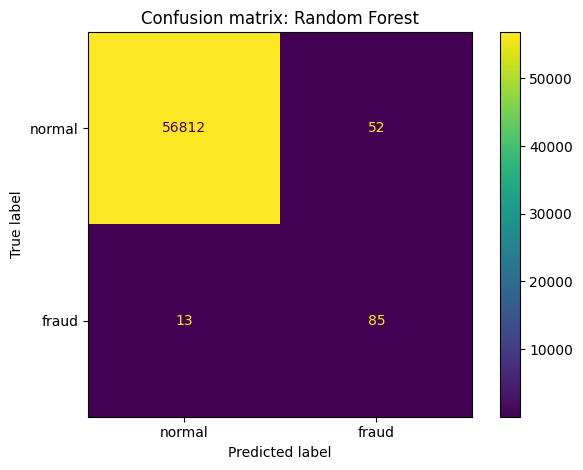

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_final = (y_proba_rf >= final_threshold).astype(int)

plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["normal", "fraud"]
)
plt.title("Confusion matrix: Random Forest")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_rf.png", dpi=300)
plt.show()

In [59]:
results.to_csv("../reports/model_comparison.csv", index=False)
threshold_df.to_csv("../reports/threshold_analysis.csv", index=False)

In [49]:
import joblib

joblib.dump(rf, MODELS_DIR / "random_forest_fraud_model.joblib")

['../models/random_forest_fraud_model.joblib']

In [50]:
import json

threshold_config = {
    "selected_threshold": final_threshold,
    "approve_threshold": 0.20,
    "review_threshold": final_threshold,
    "decision_logic": {
        "approve": "fraud_probability < 0.20",
        "review": "0.20 <= fraud_probability < 0.47",
        "block": "fraud_probability >= 0.47"
    }
}

with open(MODELS_DIR / "threshold_config.json", "w") as f:
    json.dump(threshold_config, f, indent=4)